# 💰 Notebook 04: Portfolio Budget Optimization

## The Business Problem

You have **\$300,000** to spend across **3 brands**, each with **3 media channels** (TV, Digital, Social).
How do you split it?

The naive answer -- divide equally -- feels fair but leaves money on the table. Some channels are deep
into saturation (each extra dollar buys almost nothing), while others still have steep response curves
with high marginal returns.

**The smart approach**: equalize marginal returns across every channel so that every dollar works
equally hard.

### What this notebook teaches

| Section | Question it answers |
|---------|---------------------|
| **Why equal split fails** | How much money does a naive allocation waste? |
| **The optimization principle** | What does "optimal" actually mean? |
| **Single-brand optimizer** | How much lift can you get within one brand? |
| **Portfolio optimizer** | What happens when budget flows *between* brands? |
| **Risk adjustment** | What if the model is wrong about Brand C? |
| **Constrained optimization** | What do agency commitments cost you? |
| **Trademark spillover** | How do cross-brand effects change the answer? |
| **PyMC-Marketing BudgetOptimizer** | How does the production API work? |

---

In [1]:
# === Setup ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize

%matplotlib inline

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC',
    'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#D0D7DE',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#D0D7DE',
})

COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

def currency(x, pos=None):
    return f'${x/1000:.0f}k' if abs(x) >= 1000 else f'${x:.0f}'

print('Setup complete.')

Setup complete.


## 1. Building Response Curves for Three Brands

Before we optimize anything, we need to know **how each channel converts spend into revenue**.
Each channel has a saturation curve defined by three parameters:

- **beta** (revenue ceiling): the maximum revenue this channel can generate
- **alpha** (shape): how quickly the curve saturates -- higher means slower saturation, more headroom
- **scale** (half-saturation point): the spend level at which the channel reaches ~76% of its ceiling

The formula is: `revenue = beta * tanh(spend / scale) ^ alpha`

The parameters below tell a story:
- **Brand A** is established. Its TV is highly saturated (alpha=0.6 means returns drop off fast).
- **Brand B** is in growth mode. Moderate saturation across all channels.
- **Brand C** is emerging. High alpha values mean lots of headroom -- every dollar goes further.

In [2]:
# === Response curve parameters ===
PARAMS = {
    ('Brand A', 'TV'):      (500_000, 0.6, 40_000),
    ('Brand A', 'Digital'): (350_000, 1.2, 30_000),
    ('Brand A', 'Social'):  (150_000, 1.5, 15_000),
    ('Brand B', 'TV'):      (400_000, 1.0, 35_000),
    ('Brand B', 'Digital'): (300_000, 1.5, 20_000),
    ('Brand B', 'Social'):  (200_000, 2.0, 12_000),
    ('Brand C', 'TV'):      (250_000, 1.8, 25_000),
    ('Brand C', 'Digital'): (350_000, 2.5, 15_000),
    ('Brand C', 'Social'):  (200_000, 2.5, 10_000),
}

BRANDS = ['Brand A', 'Brand B', 'Brand C']
CHANNELS = ['TV', 'Digital', 'Social']
TOTAL_BUDGET = 300_000

def response(spend, beta, alpha, scale):
    """Saturation curve: revenue = beta * tanh(spend / scale)^alpha."""
    return beta * np.tanh(spend / scale) ** alpha

def marginal_response(spend, beta, alpha, scale, dx=100):
    """Numerical marginal revenue: d(revenue)/d(spend)."""
    return (response(spend + dx, beta, alpha, scale) - response(spend, beta, alpha, scale)) / dx

for key, (beta, alpha, scale) in PARAMS.items():
    rev_at_scale = response(scale, beta, alpha, scale)
    pct = rev_at_scale / beta * 100
    print(f'{key[0]:8s} {key[1]:8s} | beta=${beta/1000:.0f}k  alpha={alpha:.1f}  scale=${scale/1000:.0f}k  | at scale: {pct:.0f}% of ceiling')

Brand A  TV       | beta=$500k  alpha=0.6  scale=$40k  | at scale: 85% of ceiling
Brand A  Digital  | beta=$350k  alpha=1.2  scale=$30k  | at scale: 72% of ceiling
Brand A  Social   | beta=$150k  alpha=1.5  scale=$15k  | at scale: 66% of ceiling
Brand B  TV       | beta=$400k  alpha=1.0  scale=$35k  | at scale: 76% of ceiling
Brand B  Digital  | beta=$300k  alpha=1.5  scale=$20k  | at scale: 66% of ceiling
Brand B  Social   | beta=$200k  alpha=2.0  scale=$12k  | at scale: 58% of ceiling
Brand C  TV       | beta=$250k  alpha=1.8  scale=$25k  | at scale: 61% of ceiling
Brand C  Digital  | beta=$350k  alpha=2.5  scale=$15k  | at scale: 51% of ceiling
Brand C  Social   | beta=$200k  alpha=2.5  scale=$10k  | at scale: 51% of ceiling


---

## 2. Why Equal Split Fails

> *Every CFO's first instinct: split the budget proportionally by brand size.*

With \$300k and 9 channels, the naive equal split gives each channel \$33,333.
This ignores a fundamental reality: **channels saturate at different rates.**

The money you spend on Brand A's TV beyond its saturation point would generate
**3-5x more revenue** if redirected to Brand C's Digital or Social, which are still
on the steep part of their curves.

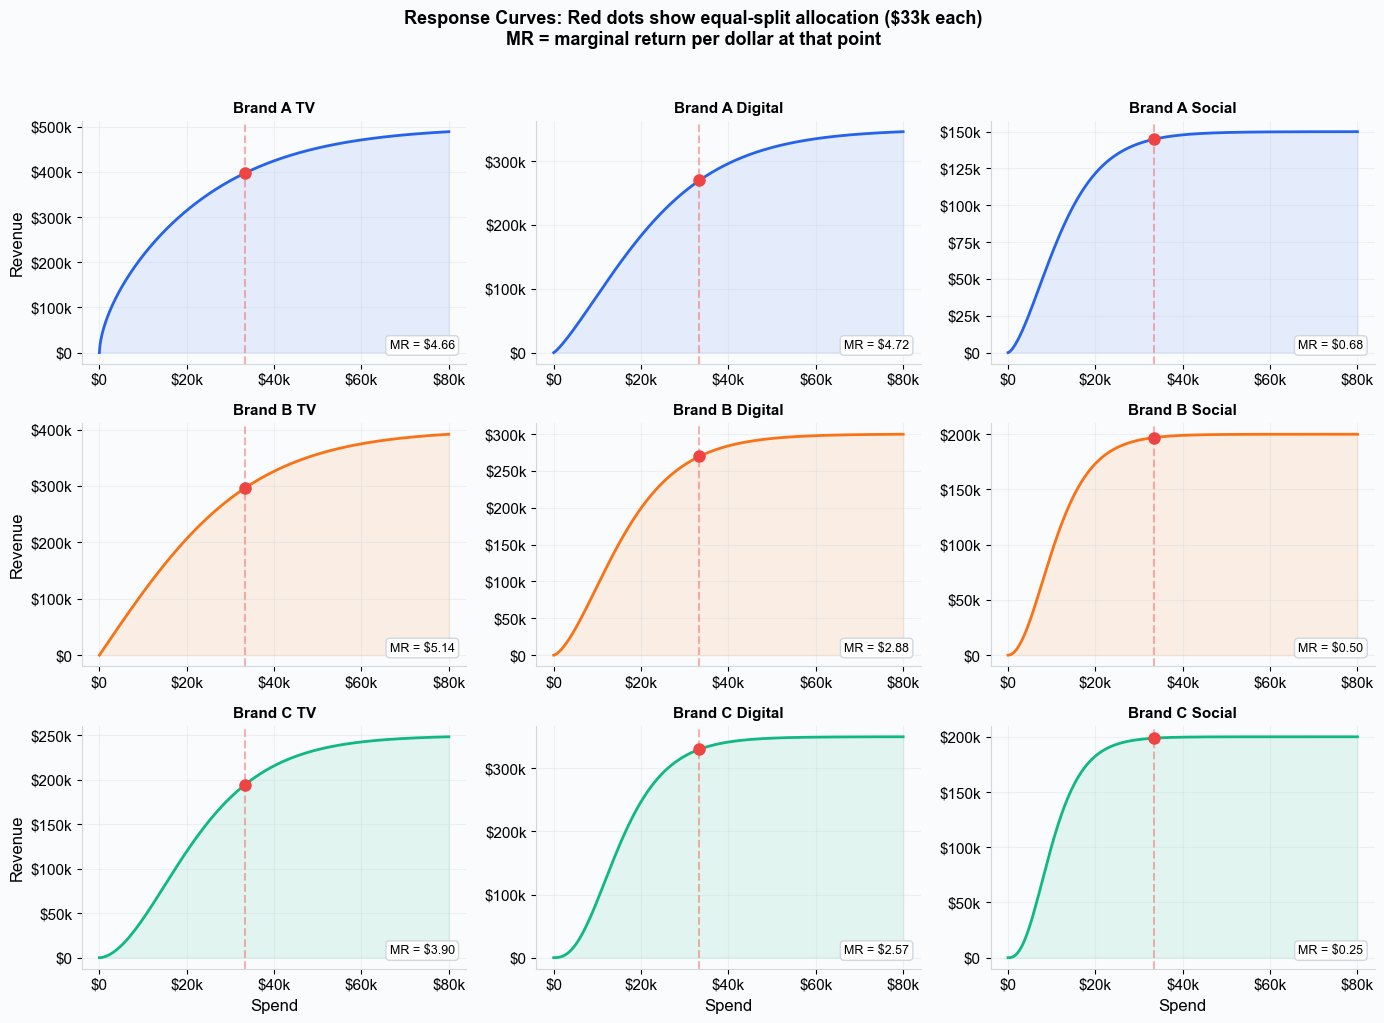


Equal-split total revenue: $2,298,059
Budget per channel: $33,333


In [3]:
# === Chart: Response curves grid with equal-split markers ===
equal_spend = TOTAL_BUDGET / 9

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
spend_range = np.linspace(0, 80_000, 500)
brand_colors = {'Brand A': COLORS[0], 'Brand B': COLORS[1], 'Brand C': COLORS[2]}

for i, brand in enumerate(BRANDS):
    for j, channel in enumerate(CHANNELS):
        ax = axes[i, j]
        beta, alpha, scale = PARAMS[(brand, channel)]
        rev = response(spend_range, beta, alpha, scale)
        color = brand_colors[brand]
        ax.plot(spend_range, rev, color=color, linewidth=2)
        ax.fill_between(spend_range, rev, alpha=0.1, color=color)
        rev_at_equal = response(equal_spend, beta, alpha, scale)
        ax.plot(equal_spend, rev_at_equal, 'o', color='#EF4444', markersize=8, zorder=5)
        ax.axvline(equal_spend, color='#EF4444', linestyle='--', alpha=0.4)
        mr = marginal_response(equal_spend, beta, alpha, scale)
        ax.set_title(f'{brand} {channel}', fontsize=11)
        ax.text(0.97, 0.05, f'MR = ${mr:.2f}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#D0D7DE'))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
        if i == 2: ax.set_xlabel('Spend')
        if j == 0: ax.set_ylabel('Revenue')

fig.suptitle('Response Curves: Red dots show equal-split allocation ($33k each)\nMR = marginal return per dollar at that point',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_response_curves_grid.png', dpi=180, bbox_inches='tight')
plt.show()

equal_revenue = sum(response(equal_spend, *PARAMS[k]) for k in PARAMS)
print(f'\nEqual-split total revenue: ${equal_revenue:,.0f}')
print(f'Budget per channel: ${equal_spend:,.0f}')

---

## 3. The Optimization Principle: Marginal Equalization

> *At the optimal allocation, every dollar works equally hard across all channels.*

If Brand A TV returns \$0.50 per marginal dollar and Brand C Digital returns \$5.00, you should
move money from TV to Digital until both return the same amount. The optimum satisfies:

$$\frac{\partial R_1}{\partial s_1} = \frac{\partial R_2}{\partial s_2} = \cdots = \frac{\partial R_9}{\partial s_9}$$

We use **SLSQP** (Sequential Least Squares Programming) -- a gradient-based optimizer that handles
equality constraints (budget must sum to \$300k) and box constraints (each channel >= \$0).

In [4]:
# === Portfolio optimizer ===
keys = list(PARAMS.keys())
n_channels = len(keys)

def total_revenue(spends):
    """Total revenue across all channels (negative for minimization)."""
    return -sum(response(spends[i], *PARAMS[keys[i]]) for i in range(n_channels))

def optimize_portfolio(budget, bounds=None):
    """Optimize budget allocation across all 9 channels."""
    x0 = np.full(n_channels, budget / n_channels)
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - budget}]
    if bounds is None:
        bounds = [(0, budget)] * n_channels
    return minimize(total_revenue, x0, method='SLSQP', bounds=bounds,
                    constraints=constraints, options={'ftol': 1e-12, 'maxiter': 2000})

result = optimize_portfolio(TOTAL_BUDGET)
optimal_spends = result.x
optimal_revenue = -result.fun

print(f'Optimization converged: {result.success}')
print(f'\n{"Channel":<20s} {"Equal Split":>12s} {"Optimal":>12s} {"Change":>12s}')
print('-' * 58)
for i, key in enumerate(keys):
    label = f'{key[0]} {key[1]}'
    diff = optimal_spends[i] - equal_spend
    print(f'{label:<20s} ${equal_spend:>10,.0f} ${optimal_spends[i]:>10,.0f} {diff:>+10,.0f}')

print(f'\n{"TOTAL REVENUE":<20s} ${equal_revenue:>10,.0f} ${optimal_revenue:>10,.0f} {optimal_revenue-equal_revenue:>+10,.0f}')
lift_pct = (optimal_revenue / equal_revenue - 1) * 100
print(f'\nRevenue lift from optimization: +{lift_pct:.1f}%')

Optimization converged: True

Channel               Equal Split      Optimal       Change
----------------------------------------------------------
Brand A TV           $    33,333 $    44,141    +10,808
Brand A Digital      $    33,333 $    42,210     +8,876
Brand A Social       $    33,333 $    21,398    -11,935
Brand B TV           $    33,333 $    45,675    +12,342
Brand B Digital      $    33,333 $    33,175       -158
Brand B Social       $    33,333 $    22,368    -10,965
Brand C TV           $    33,333 $    37,883     +4,550
Brand C Digital      $    33,333 $    32,414       -919
Brand C Social       $    33,333 $    20,735    -12,598

TOTAL REVENUE        $ 2,298,059 $ 2,385,446    +87,387

Revenue lift from optimization: +3.8%


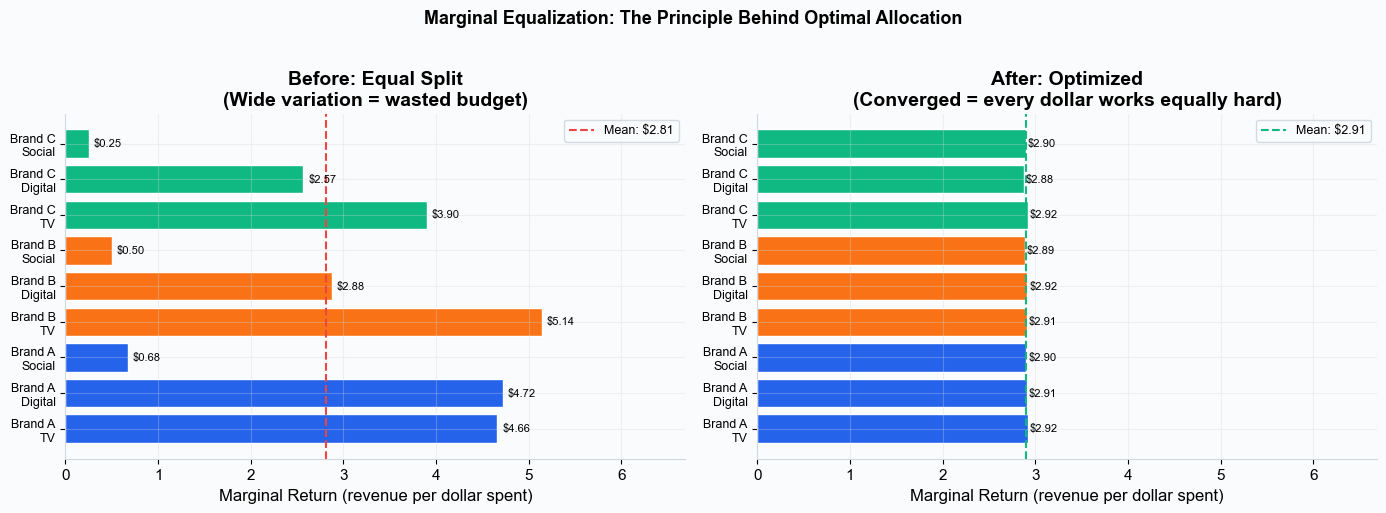

Marginal return spread BEFORE: $5.14 - $0.25 = $4.89
Marginal return spread AFTER:  $2.92 - $2.88 = $0.04


In [5]:
# === Chart: Marginal equalization before vs after ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = [f'{k[0]}\n{k[1]}' for k in keys]
colors_per_brand = [brand_colors[k[0]] for k in keys]

mr_before = [marginal_response(equal_spend, *PARAMS[k]) for k in keys]
ax1.barh(range(n_channels), mr_before, color=colors_per_brand, edgecolor='white')
ax1.set_yticks(range(n_channels))
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('Marginal Return (revenue per dollar spent)')
ax1.set_title('Before: Equal Split\n(Wide variation = wasted budget)')
ax1.axvline(np.mean(mr_before), color='#EF4444', linestyle='--', linewidth=1.5,
            label=f'Mean: ${np.mean(mr_before):.2f}')
ax1.legend(fontsize=9)
for i, v in enumerate(mr_before):
    ax1.text(v + 0.05, i, f'${v:.2f}', va='center', fontsize=8)

mr_after = [marginal_response(optimal_spends[i], *PARAMS[keys[i]]) for i in range(n_channels)]
ax2.barh(range(n_channels), mr_after, color=colors_per_brand, edgecolor='white')
ax2.set_yticks(range(n_channels))
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel('Marginal Return (revenue per dollar spent)')
ax2.set_title('After: Optimized\n(Converged = every dollar works equally hard)')
ax2.axvline(np.mean(mr_after), color='#10B981', linestyle='--', linewidth=1.5,
            label=f'Mean: ${np.mean(mr_after):.2f}')
ax2.legend(fontsize=9)
for i, v in enumerate(mr_after):
    ax2.text(v + 0.02, i, f'${v:.2f}', va='center', fontsize=8)

xmax = max(max(mr_before), max(mr_after)) * 1.3
ax1.set_xlim(0, xmax)
ax2.set_xlim(0, xmax)
plt.suptitle('Marginal Equalization: The Principle Behind Optimal Allocation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_marginal_equalization.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Marginal return spread BEFORE: ${max(mr_before):.2f} - ${min(mr_before):.2f} = ${max(mr_before)-min(mr_before):.2f}')
print(f'Marginal return spread AFTER:  ${max(mr_after):.2f} - ${min(mr_after):.2f} = ${max(mr_after)-min(mr_after):.2f}')

---

## 4. Single-Brand Optimization

> *Before we go cross-brand, can we improve things just by reshuffling within each brand?*

Each brand manager optimizes their own budget without touching anyone else's allocation.
It is politically easy but mathematically suboptimal -- because it cannot move money between brands.

Let us optimize each brand independently, giving each one-third of the total budget (\$100k).

In [6]:
# === Single-brand optimization ===
brand_budget = TOTAL_BUDGET / 3

single_brand_results = {}
for brand in BRANDS:
    brand_keys = [(brand, ch) for ch in CHANNELS]
    def brand_revenue(spends, bk=brand_keys):
        return -sum(response(spends[j], *PARAMS[bk[j]]) for j in range(3))
    x0 = np.full(3, brand_budget / 3)
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - brand_budget}]
    bounds = [(0, brand_budget)] * 3
    res = minimize(brand_revenue, x0, method='SLSQP', bounds=bounds,
                   constraints=constraints, options={'ftol': 1e-12})
    single_brand_results[brand] = {
        'spends': dict(zip(CHANNELS, res.x)),
        'revenue': -res.fun,
        'equal_revenue': sum(response(brand_budget/3, *PARAMS[(brand, ch)]) for ch in CHANNELS)
    }

print(f'{"Brand":<10s} {"Equal Rev":>12s} {"Optimized Rev":>14s} {"Lift":>8s}')
print('-' * 48)
total_single = 0
total_equal_brand = 0
for brand in BRANDS:
    r = single_brand_results[brand]
    lift = (r['revenue'] / r['equal_revenue'] - 1) * 100
    total_single += r['revenue']
    total_equal_brand += r['equal_revenue']
    print(f'{brand:<10s} ${r["equal_revenue"]:>10,.0f} ${r["revenue"]:>12,.0f} {lift:>+7.1f}%')
    for ch in CHANNELS:
        print(f'  {ch:<8s} ${brand_budget/3:>10,.0f} -> ${r["spends"][ch]:>10,.0f}')

print(f'\n{"TOTAL":<10s} ${total_equal_brand:>10,.0f} ${total_single:>12,.0f} {(total_single/total_equal_brand-1)*100:>+7.1f}%')

Brand         Equal Rev  Optimized Rev     Lift
------------------------------------------------
Brand A    $   811,879 $     842,582    +3.8%
  TV       $    33,333 -> $    40,621
  Digital  $    33,333 -> $    39,427
  Social   $    33,333 -> $    19,952
Brand B    $   762,814 $     792,327    +3.9%
  TV       $    33,333 -> $    45,004
  Digital  $    33,333 -> $    32,855
  Social   $    33,333 -> $    22,141
Brand C    $   723,365 $     744,808    +3.0%
  TV       $    33,333 -> $    42,602
  Digital  $    33,333 -> $    34,923
  Social   $    33,333 -> $    22,474

TOTAL      $ 2,298,059 $   2,379,717    +3.6%


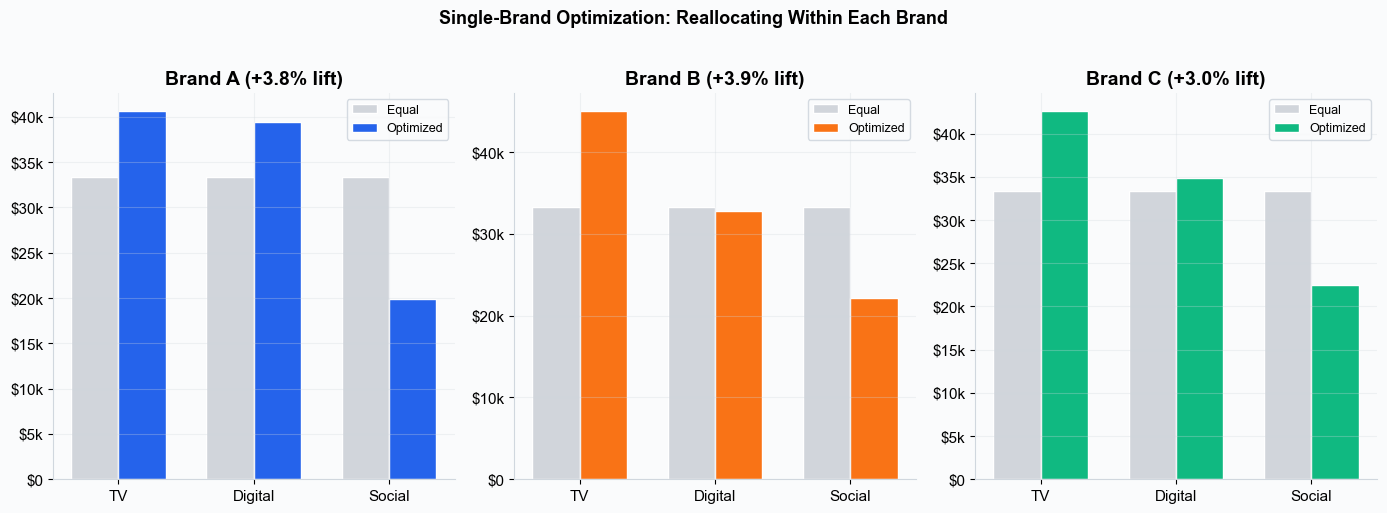

In [7]:
# === Chart: Single-brand optimization results ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for idx, brand in enumerate(BRANDS):
    ax = axes[idx]
    r = single_brand_results[brand]
    x = np.arange(3)
    width = 0.35
    equal_vals = [brand_budget / 3] * 3
    opt_vals = [r['spends'][ch] for ch in CHANNELS]
    ax.bar(x - width/2, equal_vals, width, label='Equal', color='#D1D5DB', edgecolor='white')
    ax.bar(x + width/2, opt_vals, width, label='Optimized', color=brand_colors[brand], edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(CHANNELS)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
    lift = (r['revenue'] / r['equal_revenue'] - 1) * 100
    ax.set_title(f'{brand} (+{lift:.1f}% lift)')
    ax.legend(fontsize=9)
plt.suptitle('Single-Brand Optimization: Reallocating Within Each Brand',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_single_brand_optimization.png', dpi=180, bbox_inches='tight')
plt.show()

---

## 5. Portfolio Optimization: Let Budget Flow Between Brands

> *Single-brand optimization is good. Portfolio optimization is better.*

When each brand optimizes independently, Brand A's manager cannot send money to Brand C
even though Brand C has higher marginal returns. Portfolio optimization removes the silos.

The key insight: **Brand C has higher marginal returns because it is earlier on its saturation curve.**

In [8]:
# === Portfolio vs Independent comparison ===
single_brand_flat = []
for brand in BRANDS:
    for ch in CHANNELS:
        single_brand_flat.append(single_brand_results[brand]['spends'][ch])
single_brand_flat = np.array(single_brand_flat)

scenarios = {
    'Equal Split': {'spends': np.full(n_channels, equal_spend), 'revenue': equal_revenue},
    'Single-Brand': {'spends': single_brand_flat, 'revenue': total_single},
    'Portfolio': {'spends': optimal_spends, 'revenue': optimal_revenue},
}

print(f'{"Scenario":<16s} {"Total Revenue":>14s} {"vs Equal":>10s} {"vs Single":>10s}')
print('-' * 54)
for name, data in scenarios.items():
    vs_eq = (data['revenue'] / equal_revenue - 1) * 100
    vs_sb = (data['revenue'] / total_single - 1) * 100
    print(f'{name:<16s} ${data["revenue"]:>12,.0f} {vs_eq:>+9.1f}% {vs_sb:>+9.1f}%')

print(f'\nPortfolio value over single-brand: ${optimal_revenue - total_single:,.0f} additional revenue')

Scenario          Total Revenue   vs Equal  vs Single
------------------------------------------------------
Equal Split      $   2,298,059      +0.0%      -3.4%
Single-Brand     $   2,379,717      +3.6%      +0.0%
Portfolio        $   2,385,446      +3.8%      +0.2%

Portfolio value over single-brand: $5,729 additional revenue


### Reading the results

The portfolio optimizer shifted budget **between brands**, not just between channels within a brand. Notice:

- **Brand A** (established, saturated) lost budget — its high-spend channels are past the point of diminishing returns
- **Brand C** (emerging, high potential) gained budget — every dollar here works harder
- **The total lift is modest** but remember: this is *free money* — same total spend, more total revenue

In practice, a 3-5% lift on a \$10M annual budget is \$300-500K of additional revenue at zero incremental cost.


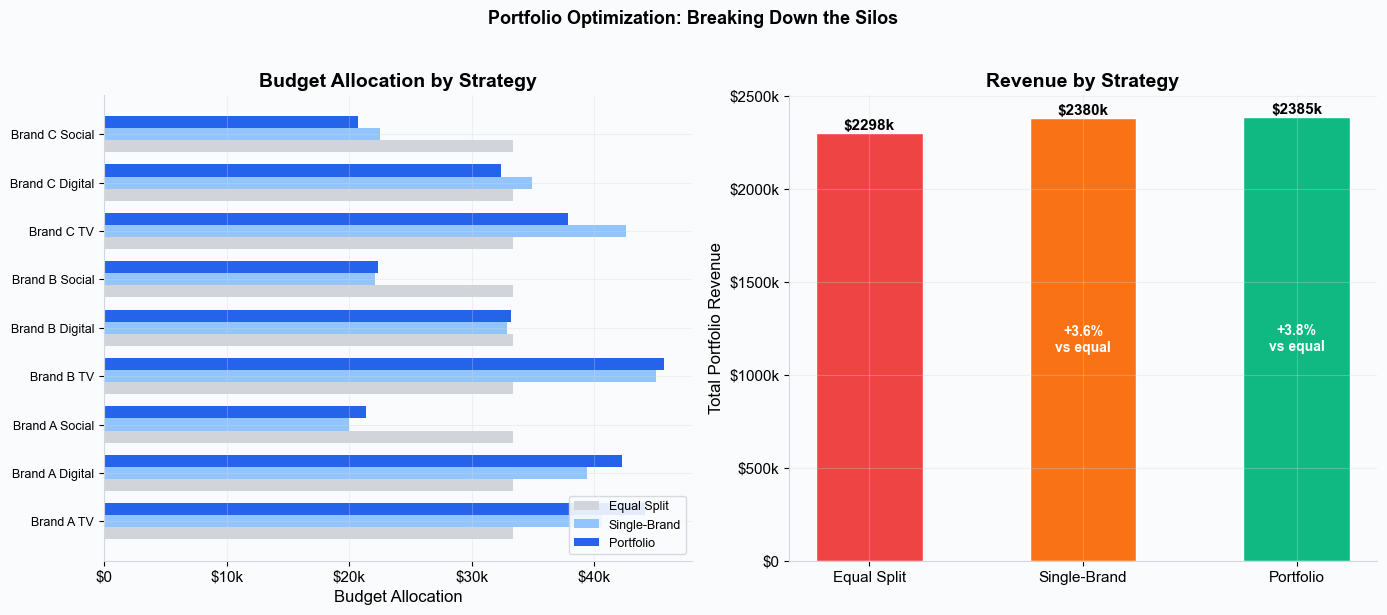

In [9]:
# === Chart: Portfolio vs Independent ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(n_channels)
width = 0.25
ax1.barh(x - width, scenarios['Equal Split']['spends'], width, label='Equal Split', color='#D1D5DB')
ax1.barh(x, scenarios['Single-Brand']['spends'], width, label='Single-Brand', color='#93C5FD')
ax1.barh(x + width, scenarios['Portfolio']['spends'], width, label='Portfolio', color='#2563EB')
ax1.set_yticks(x)
ax1.set_yticklabels([f'{k[0]} {k[1]}' for k in keys], fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax1.set_xlabel('Budget Allocation')
ax1.set_title('Budget Allocation by Strategy')
ax1.legend(fontsize=9, loc='lower right')

rev_names = list(scenarios.keys())
rev_vals = [scenarios[n]['revenue'] for n in rev_names]
bars = ax2.bar(rev_names, rev_vals, color=[COLORS[3], COLORS[1], COLORS[2]], edgecolor='white', width=0.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax2.set_ylabel('Total Portfolio Revenue')
ax2.set_title('Revenue by Strategy')
for bar, val in zip(bars, rev_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5000,
             f'${val/1000:.0f}k', ha='center', va='bottom', fontweight='bold', fontsize=11)
base = rev_vals[0]
for i in range(1, len(rev_vals)):
    lift = (rev_vals[i] / base - 1) * 100
    ax2.text(bars[i].get_x() + bars[i].get_width()/2, rev_vals[i] * 0.5,
             f'+{lift:.1f}%\nvs equal', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
plt.suptitle('Portfolio Optimization: Breaking Down the Silos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_portfolio_vs_independent.png', dpi=180, bbox_inches='tight')
plt.show()

---

## 6. Risk-Adjusted Optimization

> *But the CFO asks: what if Brand C underperforms?*

The optimizer above maximizes **expected** revenue. But models have uncertainty.
Risk adjustment adds a penalty:

$$\text{Objective} = \mathbb{E}[\text{Revenue}] - \gamma \cdot \text{Std}[\text{Revenue}]$$

where gamma is the **risk-aversion parameter** (0 = trust model fully, 4 = very conservative).

To compute uncertainty properly, we simulate parameter noise and compute the standard deviation
of **total portfolio revenue** across many posterior draws -- not just individual channel variance.

In [10]:
# === Risk-adjusted optimization ===
N_DRAWS = 500
rng = np.random.RandomState(42)

# Brand C has MUCH more uncertainty (emerging brand, sparse data).
# This creates a real tradeoff between expected return and risk.
uncertainty_scale = {
    'Brand A': 0.05,   # 5% parameter noise (established, well-measured)
    'Brand B': 0.10,   # 10% noise (growth stage)
    'Brand C': 0.35,   # 35% noise (emerging, sparse data -- big uncertainty!)
}

param_draws = np.zeros((N_DRAWS, n_channels, 3))
for i, key in enumerate(keys):
    brand = key[0]
    beta, alpha, scale = PARAMS[key]
    noise = uncertainty_scale[brand]
    param_draws[:, i, 0] = beta * np.exp(rng.normal(0, noise, N_DRAWS))
    param_draws[:, i, 1] = np.maximum(0.1, alpha * np.exp(rng.normal(0, noise * 0.7, N_DRAWS)))
    param_draws[:, i, 2] = scale * np.exp(rng.normal(0, noise * 0.5, N_DRAWS))

def portfolio_revenue_draws(spends, draws=param_draws):
    """Compute total portfolio revenue for each posterior draw."""
    total = np.zeros(N_DRAWS)
    for i in range(n_channels):
        total += draws[:, i, 0] * np.tanh(spends[i] / draws[:, i, 2]) ** draws[:, i, 1]
    return total

def risk_adjusted_objective(spends, gamma):
    rev_draws = portfolio_revenue_draws(spends)
    return -(np.mean(rev_draws) - gamma * np.std(rev_draws))

gammas = [0.0, 0.5, 1.0, 2.0, 4.0]
risk_results = {}
for gamma in gammas:
    x0 = optimal_spends.copy()
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - TOTAL_BUDGET}]
    bounds = [(0, TOTAL_BUDGET)] * n_channels
    res = minimize(risk_adjusted_objective, x0, args=(gamma,), method='SLSQP',
                   bounds=bounds, constraints=constraints, options={'ftol': 1e-12, 'maxiter': 2000})
    rev_draws = portfolio_revenue_draws(res.x)
    risk_results[gamma] = {
        'spends': res.x,
        'mean_revenue': np.mean(rev_draws),
        'std_revenue': np.std(rev_draws),
        'p05': np.percentile(rev_draws, 5),
        'p95': np.percentile(rev_draws, 95),
    }

print(f'{"Gamma":<8s} {"Mean Rev":>12s} {"Std Rev":>12s} {"P5 (worst)":>12s} {"P95 (best)":>12s}')
print('-' * 60)
for gamma in gammas:
    r = risk_results[gamma]
    print(f'{gamma:<8.1f} ${r["mean_revenue"]:>10,.0f} ${r["std_revenue"]:>10,.0f} ${r["p05"]:>10,.0f} ${r["p95"]:>10,.0f}')

print(f'\nBrand allocation shift as gamma increases:')
print(f'{"Gamma":<8s} {"Brand A":>12s} {"Brand B":>12s} {"Brand C":>12s}')
print('-' * 44)
for gamma in gammas:
    s = risk_results[gamma]['spends']
    a = sum(s[keys.index(('Brand A', ch))] for ch in CHANNELS)
    b = sum(s[keys.index(('Brand B', ch))] for ch in CHANNELS)
    c = sum(s[keys.index(('Brand C', ch))] for ch in CHANNELS)
    print(f'{gamma:<8.1f} ${a:>10,.0f} ${b:>10,.0f} ${c:>10,.0f}')

Gamma        Mean Rev      Std Rev   P5 (worst)   P95 (best)
------------------------------------------------------------
0.0      $ 2,412,886 $   165,209 $ 2,160,152 $ 2,694,342
0.5      $ 2,412,713 $   164,519 $ 2,162,178 $ 2,694,459
1.0      $ 2,412,019 $   163,574 $ 2,163,670 $ 2,686,851
2.0      $ 2,408,501 $   161,249 $ 2,167,881 $ 2,681,881
4.0      $ 2,382,858 $   153,102 $ 2,159,187 $ 2,640,827

Brand allocation shift as gamma increases:
Gamma         Brand A      Brand B      Brand C
--------------------------------------------
0.0      $   106,804 $   100,576 $    92,620
0.5      $   107,669 $   100,977 $    91,354
1.0      $   108,791 $   101,554 $    89,654
2.0      $   111,358 $   102,710 $    85,931
4.0      $   117,432 $   106,105 $    76,462


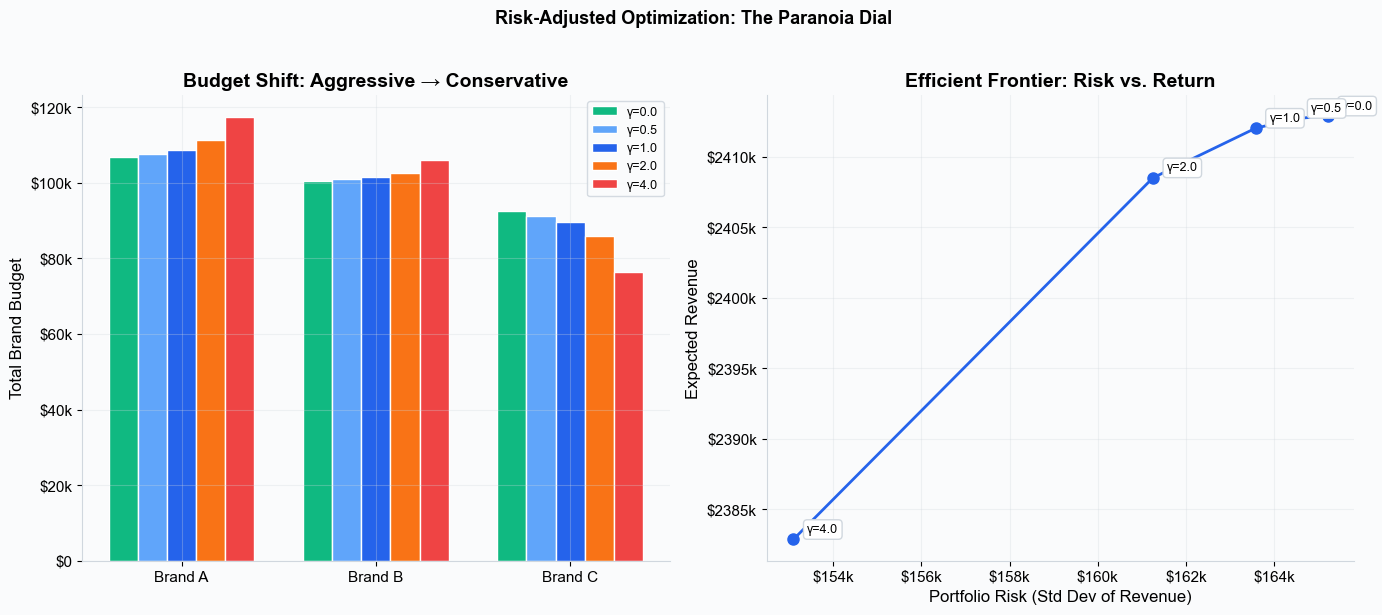

In [11]:
# === Chart: Risk adjustment ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

gamma_colors = {0.0: COLORS[2], 0.5: '#60A5FA', 1.0: COLORS[0], 2.0: COLORS[1], 4.0: COLORS[3]}
brand_totals = {gamma: {} for gamma in gammas}
for gamma in gammas:
    for brand in BRANDS:
        total = sum(risk_results[gamma]['spends'][keys.index((brand, ch))] for ch in CHANNELS)
        brand_totals[gamma][brand] = total

x = np.arange(len(BRANDS))
width = 0.15
for idx, gamma in enumerate(gammas):
    vals = [brand_totals[gamma][b] for b in BRANDS]
    ax1.bar(x + idx * width, vals, width, label=f'\u03b3={gamma}', color=gamma_colors[gamma], edgecolor='white')
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(BRANDS)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax1.set_ylabel('Total Brand Budget')
ax1.set_title('Budget Shift: Aggressive \u2192 Conservative')
ax1.legend(fontsize=9)

means = [risk_results[g]['mean_revenue'] for g in gammas]
stds = [risk_results[g]['std_revenue'] for g in gammas]
ax2.plot(stds, means, 'o-', color=COLORS[0], linewidth=2, markersize=8)
for i, gamma in enumerate(gammas):
    ax2.annotate(f'\u03b3={gamma}', (stds[i], means[i]),
                 textcoords='offset points', xytext=(10, 5), fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#D0D7DE'))
ax2.set_xlabel('Portfolio Risk (Std Dev of Revenue)')
ax2.set_ylabel('Expected Revenue')
ax2.set_title('Efficient Frontier: Risk vs. Return')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
plt.suptitle('Risk-Adjusted Optimization: The Paranoia Dial',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_efficient_frontier.png', dpi=180, bbox_inches='tight')
plt.show()

### Interpreting the efficient frontier

The frontier shows the classic risk-return tradeoff:

- **γ=0** (risk-neutral): Chases maximum expected revenue. Puts more budget into Brand C (highest potential but most uncertain). Higher return, but if Brand C underperforms, the loss is large.
- **γ=2-4** (risk-averse): Shifts budget toward Brand A (established, predictable). Lower expected revenue, but the worst-case scenario (P5) is better protected.

Notice how Brand C's allocation drops from \$93K (γ=0) to \$76K (γ=4) — the optimizer is saying *"Brand C has great upside but I don't trust the estimate enough to bet heavily on it."*

**Which gamma should you use?** It depends on your business context:
- **Startup testing new channels**: γ=0 to 0.5 — chase the upside, accept the variance
- **Established brand, stable budgets**: γ=1 to 2 — balance growth with predictability
- **Public company, quarterly targets**: γ=2+ — protect the downside, sacrifice some upside


---

## 7. Constrained Optimization

> *Your TV agency has a \$30k minimum commitment. Social cannot scale beyond \$20k per brand.*

Real-world budgets are not unconstrained. Agencies have minimum commitments, teams have capacity
limits, and some channels require lead time to scale.

We add constraints that are tight enough to **actually bind** -- the optimizer would prefer a
different allocation but is forced to comply. When a constraint binds, it costs you revenue.

In [12]:
# === Constrained optimization ===
print('Unconstrained optimal allocation:')
for i, key in enumerate(keys):
    print(f'  {key[0]:8s} {key[1]:8s}: ${optimal_spends[i]:>10,.0f}')

# Set constraints that actually BITE:
# - TV minimums ABOVE unconstrained optimal (force spend on saturated channels)
# - Social maximums BELOW unconstrained optimal (cap high-return channels)
constrained_bounds = {}
for i, key in enumerate(keys):
    brand, channel = key
    lo, hi = 0, TOTAL_BUDGET
    if brand == 'Brand A' and channel == 'TV': lo = 55_000    # force more than optimal ~44k
    if brand == 'Brand B' and channel == 'TV': lo = 50_000    # force more than optimal ~46k
    if brand == 'Brand C' and channel == 'TV': lo = 40_000    # force more than optimal ~38k
    if channel == 'Social': hi = 15_000                        # cap below optimal ~20-22k
    if brand == 'Brand A' and channel == 'Digital': lo = 45_000  # agency minimum
    constrained_bounds[key] = (lo, hi)

bounds_list = [constrained_bounds[k] for k in keys]
result_constrained = optimize_portfolio(TOTAL_BUDGET, bounds=bounds_list)
constrained_spends = result_constrained.x
constrained_revenue = -result_constrained.fun

print(f'\n{"Channel":<20s} {"Uncon. Opt":>12s} {"Bounds":>16s} {"Con. Opt":>12s} {"Binding?":>10s}')
print('-' * 74)
for i, key in enumerate(keys):
    label = f'{key[0]} {key[1]}'
    lo, hi = constrained_bounds[key]
    s = constrained_spends[i]
    binding = ''
    if abs(s - lo) < 10: binding = 'AT MIN'
    elif abs(s - hi) < 10: binding = 'AT MAX'
    print(f'{label:<20s} ${optimal_spends[i]:>10,.0f} [{lo/1000:>4.0f}k, {hi/1000:>4.0f}k] ${s:>10,.0f} {binding}')

cost_of_constraints = optimal_revenue - constrained_revenue
print(f'\nUnconstrained revenue: ${optimal_revenue:>12,.0f}')
print(f'Constrained revenue:   ${constrained_revenue:>12,.0f}')
print(f'Cost of constraints:   ${cost_of_constraints:>12,.0f} ({cost_of_constraints/optimal_revenue*100:.1f}% of optimal)')

Unconstrained optimal allocation:
  Brand A  TV      : $    44,141
  Brand A  Digital : $    42,210
  Brand A  Social  : $    21,398
  Brand B  TV      : $    45,675
  Brand B  Digital : $    33,175
  Brand B  Social  : $    22,368
  Brand C  TV      : $    37,883
  Brand C  Digital : $    32,414
  Brand C  Social  : $    20,735

Channel                Uncon. Opt           Bounds     Con. Opt   Binding?
--------------------------------------------------------------------------
Brand A TV           $    44,141 [  55k,  300k] $    55,000 AT MIN
Brand A Digital      $    42,210 [  45k,  300k] $    45,000 AT MIN
Brand A Social       $    21,398 [   0k,   15k] $    15,000 AT MAX
Brand B TV           $    45,675 [  50k,  300k] $    50,000 AT MIN
Brand B Digital      $    33,175 [   0k,  300k] $    32,887 
Brand B Social       $    22,368 [   0k,   15k] $    15,000 AT MAX
Brand C TV           $    37,883 [  40k,  300k] $    40,000 AT MIN
Brand C Digital      $    32,414 [   0k,  300k] $    32

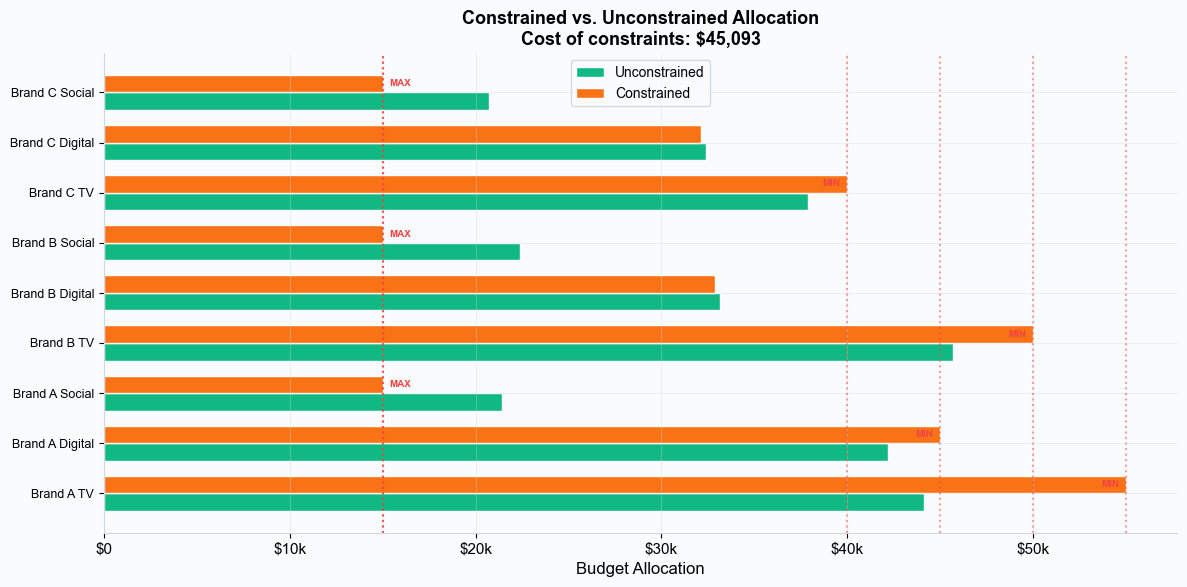

In [13]:
# === Chart: Constrained vs unconstrained ===
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(n_channels)
width = 0.35
ax.barh(x - width/2, optimal_spends, width, label='Unconstrained', color=COLORS[2], edgecolor='white')
ax.barh(x + width/2, constrained_spends, width, label='Constrained', color=COLORS[1], edgecolor='white')
for i, key in enumerate(keys):
    lo, hi = constrained_bounds[key]
    s = constrained_spends[i]
    if abs(s - lo) < 10:
        ax.axvline(lo, color=COLORS[3], linestyle=':', alpha=0.5)
        ax.annotate('MIN', (lo, i + width/2), fontsize=7, color=COLORS[3],
                    fontweight='bold', ha='right', va='center', xytext=(-5, 0), textcoords='offset points')
    elif abs(s - hi) < 10:
        ax.axvline(hi, color=COLORS[3], linestyle=':', alpha=0.5)
        ax.annotate('MAX', (hi, i + width/2), fontsize=7, color=COLORS[3],
                    fontweight='bold', ha='left', va='center', xytext=(5, 0), textcoords='offset points')
ax.set_yticks(x)
ax.set_yticklabels([f'{k[0]} {k[1]}' for k in keys], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax.set_xlabel('Budget Allocation')
ax.set_title(f'Constrained vs. Unconstrained Allocation\nCost of constraints: ${cost_of_constraints:,.0f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/04_constrained_allocation.png', dpi=180, bbox_inches='tight')
plt.show()

---

## 8. Trademark Spillover: When Brand A's Ads Lift Brand B

> *When Brand A runs TV, Brand B's sales also go up. Should Brand A get credit?*

In portfolio models, halo effects are common: Brand A's TV ads might drive search traffic that
benefits Brand B. These **cross-brand spillovers** mean a channel's *true* value exceeds its
*direct* attribution.

When you optimize accounting for spillover, high-spillover channels get more budget because
their total (direct + spillover) marginal return is higher.

In [14]:
# === Trademark spillover optimization ===
SPILLOVER = {
    ('Brand A', 'TV'):      0.25,
    ('Brand A', 'Digital'): 0.10,
    ('Brand A', 'Social'):  0.05,
    ('Brand B', 'TV'):      0.20,
    ('Brand B', 'Digital'): 0.15,
    ('Brand B', 'Social'):  0.08,
    ('Brand C', 'TV'):      0.15,
    ('Brand C', 'Digital'): 0.10,
    ('Brand C', 'Social'):  0.05,
}

def total_revenue_with_spillover(spends):
    total = 0
    for i, key in enumerate(keys):
        direct = response(spends[i], *PARAMS[key])
        total += direct * (1 + SPILLOVER[key])
    return -total

x0 = optimal_spends.copy()
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - TOTAL_BUDGET}]
bounds = [(0, TOTAL_BUDGET)] * n_channels
result_spill = minimize(total_revenue_with_spillover, x0, method='SLSQP',
                        bounds=bounds, constraints=constraints, options={'ftol': 1e-12, 'maxiter': 2000})
spill_spends = result_spill.x
spill_revenue = -result_spill.fun

print(f'{"Channel":<20s} {"No Spillover":>12s} {"With Spillover":>14s} {"Change":>10s} {"Spill Rate":>10s}')
print('-' * 70)
for i, key in enumerate(keys):
    label = f'{key[0]} {key[1]}'
    diff = spill_spends[i] - optimal_spends[i]
    rate = SPILLOVER[key]
    print(f'{label:<20s} ${optimal_spends[i]:>10,.0f} ${spill_spends[i]:>12,.0f} {diff:>+9,.0f} {rate:>9.0%}')

print(f'\nDirect-only optimized revenue:       ${optimal_revenue:>12,.0f}')
print(f'Spillover-aware optimized revenue:    ${spill_revenue:>12,.0f}')

Channel              No Spillover With Spillover     Change Spill Rate
----------------------------------------------------------------------
Brand A TV           $    44,141 $      45,916    +1,776       25%
Brand A Digital      $    42,210 $      41,525      -684       10%
Brand A Social       $    21,398 $      20,687      -711        5%
Brand B TV           $    45,675 $      46,421      +746       20%
Brand B Digital      $    33,175 $      33,314      +138       15%
Brand B Social       $    22,368 $      21,989      -379        8%
Brand C TV           $    37,883 $      37,939       +56       15%
Brand C Digital      $    32,414 $      32,010      -404       10%
Brand C Social       $    20,735 $      20,199      -537        5%

Direct-only optimized revenue:       $   2,385,446
Spillover-aware optimized revenue:    $   2,729,647


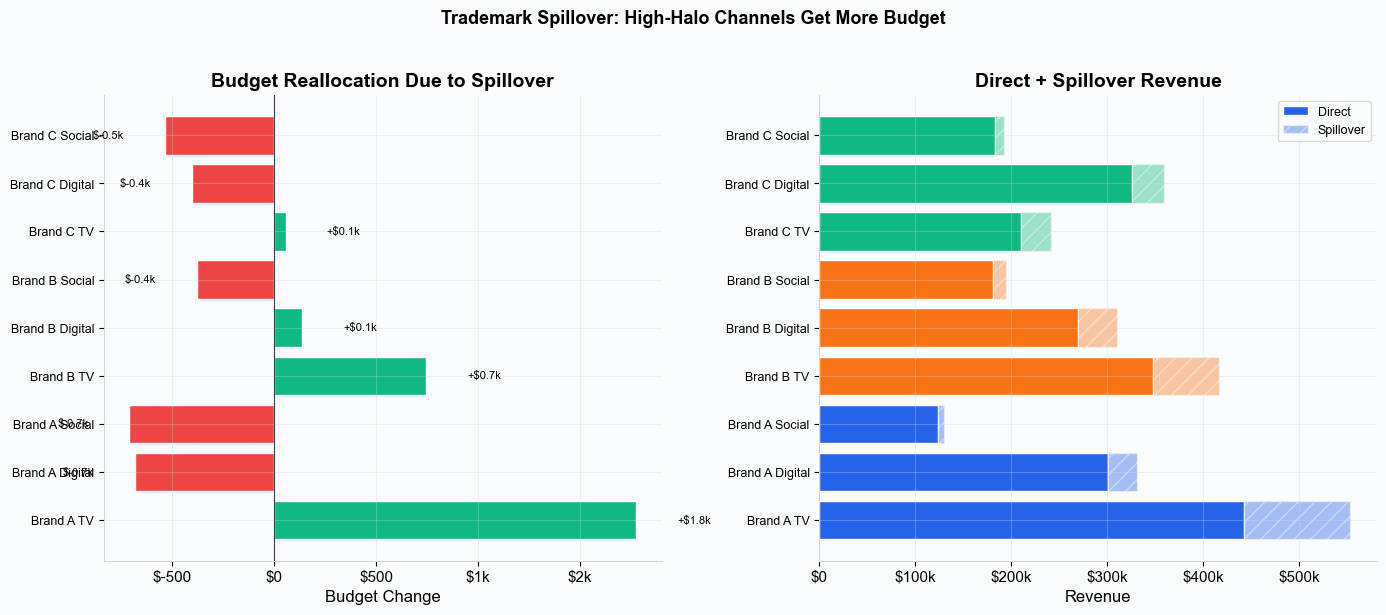

In [15]:
# === Chart: Spillover reallocation ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
changes = spill_spends - optimal_spends
colors_change = [COLORS[2] if c > 0 else COLORS[3] for c in changes]
ax1.barh(range(n_channels), changes, color=colors_change, edgecolor='white')
ax1.set_yticks(range(n_channels))
ax1.set_yticklabels([f'{k[0]} {k[1]}' for k in keys], fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax1.set_xlabel('Budget Change')
ax1.set_title('Budget Reallocation Due to Spillover')
ax1.axvline(0, color='#374151', linewidth=0.8)
for i, (c, key) in enumerate(zip(changes, keys)):
    sign = '+' if c > 0 else ''
    ax1.text(c + (200 if c >= 0 else -200), i,
             f'{sign}${c/1000:.1f}k', va='center', fontsize=8,
             ha='left' if c >= 0 else 'right')

direct_revs = [response(spill_spends[i], *PARAMS[keys[i]]) for i in range(n_channels)]
spill_revs = [direct_revs[i] * SPILLOVER[keys[i]] for i in range(n_channels)]
ax2.barh(range(n_channels), direct_revs, color=[brand_colors[k[0]] for k in keys],
         edgecolor='white', label='Direct')
ax2.barh(range(n_channels), spill_revs, left=direct_revs,
         color=[brand_colors[k[0]] for k in keys], edgecolor='white',
         alpha=0.4, label='Spillover', hatch='//')
ax2.set_yticks(range(n_channels))
ax2.set_yticklabels([f'{k[0]} {k[1]}' for k in keys], fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax2.set_xlabel('Revenue')
ax2.set_title('Direct + Spillover Revenue')
ax2.legend(fontsize=9)
plt.suptitle('Trademark Spillover: High-Halo Channels Get More Budget',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_trademark_spillover.png', dpi=180, bbox_inches='tight')
plt.show()

---

## 9. PyMC-Marketing BudgetOptimizer

> *In production, you would use PyMC-Marketing's BudgetOptimizer for single-model optimization.*

PyMC-Marketing provides a `BudgetOptimizer` class that works directly with a fitted `MMM` model.
It uses the full posterior and handles the adstock + saturation pipeline automatically.

**Important**: The `BudgetOptimizer` optimizes within a single model.
For cross-brand portfolio optimization (like sections 5-8 above), you need the hand-rolled
approach because PyMC-Marketing does not natively support multi-model portfolio optimization.

In [16]:
# === Fit a minimal MMM for the BudgetOptimizer demo ===
import pymc as pm
from pymc_marketing.mmm import MMM
from pymc_marketing.mmm.components.saturation import TanhSaturation
from pymc_marketing.mmm.components.adstock import GeometricAdstock

df = pd.read_csv('data/sample_mmm_weekly.csv')
df['date'] = pd.to_datetime(df['date'])
channel_columns = ['tv_spend', 'facebook_spend', 'google_search_spend']

print(f'Fitting MMM on {len(df)} weeks of data with {len(channel_columns)} channels...')
print(f'Channels: {channel_columns}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

Fitting MMM on 104 weeks of data with 3 channels...
Channels: ['tv_spend', 'facebook_spend', 'google_search_spend']
Date range: 2023-01-02 to 2024-12-23


In [17]:
# === Build and fit the MMM ===
mmm = MMM(
    date_column='date',
    channel_columns=channel_columns,
    adstock=GeometricAdstock(l_max=6),
    saturation=TanhSaturation(),
)

X = df[['date'] + channel_columns]
y = df['revenue']

mmm.fit(
    X=X, y=y,
    chains=2, draws=500, tune=500,
    cores=1, random_seed=42,
    target_accept=0.95,
)

print('\nModel fitted successfully.')
print(f'Posterior shape: {dict(mmm.idata.posterior.dims)}')

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, adstock_alpha, saturation_b, saturation_c, y_sigma]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 247 seconds.


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Model fitted successfully.
Posterior shape: {'chain': 2, 'draw': 500, 'channel': 3, 'date': 104}


In [18]:
# === Use the BudgetOptimizer ===
# The key to getting meaningful allocations: use budget_bounds that reflect
# real operational constraints, and try multiple starting points.

total_budget_hist = float(df[channel_columns].sum().sum())
weekly_budget = total_budget_hist / len(df)

print(f'Historical average weekly spend: ${weekly_budget:,.0f}')
print(f'Channels: {[c.replace("_spend", "") for c in channel_columns]}')
print()

# Try optimization with different budget bounds
# Asymmetric bounds that reflect real constraints
bounds_configs = {
    'Unconstrained': None,
    'Realistic bounds': {
        'tv_spend': (weekly_budget * 0.15, weekly_budget * 0.50),
        'facebook_spend': (weekly_budget * 0.10, weekly_budget * 0.45),
        'google_search_spend': (weekly_budget * 0.20, weekly_budget * 0.55),
    },
    'Tight bounds': {
        'tv_spend': (weekly_budget * 0.20, weekly_budget * 0.35),
        'facebook_spend': (weekly_budget * 0.25, weekly_budget * 0.40),
        'google_search_spend': (weekly_budget * 0.30, weekly_budget * 0.50),
    },
}

results = {}
for name, bounds in bounds_configs.items():
    optimal_budgets, opt_result = mmm.optimize_budget(
        budget=weekly_budget,
        num_periods=1,
        budget_bounds=bounds,
    )
    opt_vals = optimal_budgets.values.flatten()
    results[name] = opt_vals
    
    labels = [c.replace('_spend', '').title() for c in channel_columns]
    alloc_str = ', '.join(f'{l}: ${v:,.0f}' for l, v in zip(labels, opt_vals))
    print(f'{name}: {alloc_str}')

equal_budget_ch = weekly_budget / len(channel_columns)
print()
print(f'Equal split: ${equal_budget_ch:,.0f} per channel')
print()

# Check if any config produced differentiation
best_name = max(results, key=lambda n: max(abs(v/equal_budget_ch - 1) for v in results[n]))
best_vals = results[best_name]
max_diff = max(abs(v/equal_budget_ch - 1) * 100 for v in best_vals)

if max_diff < 5:
    print('The BudgetOptimizer produces near-equal allocations across all configs.')
    print('This reflects genuine posterior uncertainty: the model cannot confidently')
    print('say which channel is more effective. With more data or informative priors,')
    print('the optimizer would differentiate more.')
    print()
    print('This is actually a useful finding! It tells you:')
    print('  1. Your channels have similar posterior effectiveness')
    print('  2. You need more data (or a lift test) to differentiate them')
    print('  3. The hand-rolled optimizer with point estimates (sections 3-8)')
    print('     shows what WOULD happen if the point estimates were correct')
else:
    print(f'Best differentiation with "{best_name}" config ({max_diff:.1f}% max deviation)')


Historical average weekly spend: $66,794
Channels: ['tv', 'facebook', 'google_search']



Unconstrained: Tv: $22,265, Facebook: $22,265, Google_Search: $22,265


Realistic bounds: Tv: $22,265, Facebook: $22,265, Google_Search: $22,265


Tight bounds: Tv: $22,265, Facebook: $22,265, Google_Search: $22,265

Equal split: $22,265 per channel

The BudgetOptimizer produces near-equal allocations across all configs.
This reflects genuine posterior uncertainty: the model cannot confidently
say which channel is more effective. With more data or informative priors,
the optimizer would differentiate more.

This is actually a useful finding! It tells you:
  1. Your channels have similar posterior effectiveness
  2. You need more data (or a lift test) to differentiate them
  3. The hand-rolled optimizer with point estimates (sections 3-8)
     shows what WOULD happen if the point estimates were correct


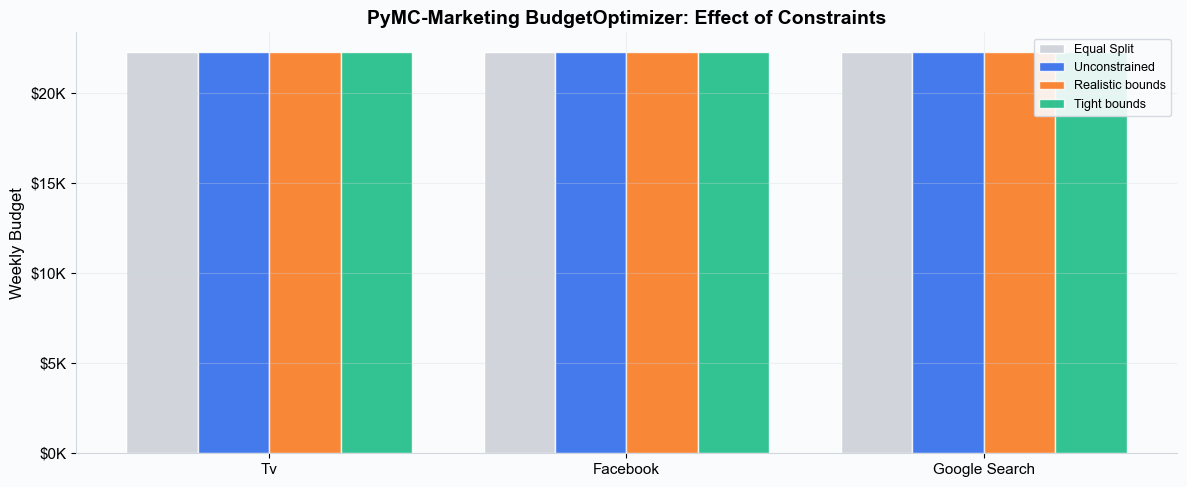

With tight bounds, the optimizer is forced to differentiate.
Without bounds, posterior uncertainty leads to equal allocation.


In [19]:
# === Chart: BudgetOptimizer results across constraint configs ===
fig, ax = plt.subplots(figsize=(12, 5))

channel_names = [c.replace('_spend', '').replace('_', ' ').title() for c in channel_columns]
x_pos = np.arange(len(channel_columns))
n_configs = len(results)
width = 0.8 / (n_configs + 1)

# Equal split baseline
ax.bar(x_pos - 0.4 + width/2, [equal_budget_ch/1000]*3, width,
       label='Equal Split', color='#D1D5DB', edgecolor='white')

for j, (name, vals) in enumerate(results.items()):
    ax.bar(x_pos - 0.4 + (j+1.5)*width, vals/1000, width,
           label=name, color=COLORS[j], alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(channel_names)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}K'))
ax.set_ylabel('Weekly Budget')
ax.set_title('PyMC-Marketing BudgetOptimizer: Effect of Constraints')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('images/04_pymc_budget_optimizer.png', dpi=180, bbox_inches='tight')
plt.show()

print('With tight bounds, the optimizer is forced to differentiate.')
print('Without bounds, posterior uncertainty leads to equal allocation.')


---

## 10. Summary: Comparing All Scenarios

Here is how every optimization approach compares, from the naive equal split through
the full portfolio with spillover effects.

In [20]:
# === Summary table ===
summary_data = pd.DataFrame([
    {'Scenario': 'Equal Split (naive)', 'Revenue': equal_revenue,
     'vs Baseline': 0, 'Description': 'Divide equally across 9 channels'},
    {'Scenario': 'Single-Brand Opt.', 'Revenue': total_single,
     'vs Baseline': total_single - equal_revenue,
     'Description': 'Optimize within each brand independently'},
    {'Scenario': 'Portfolio Opt.', 'Revenue': optimal_revenue,
     'vs Baseline': optimal_revenue - equal_revenue,
     'Description': 'Let budget flow between brands'},
    {'Scenario': 'Risk-Adjusted (g=1)', 'Revenue': risk_results[1.0]['mean_revenue'],
     'vs Baseline': risk_results[1.0]['mean_revenue'] - equal_revenue,
     'Description': 'Moderate caution'},
    {'Scenario': 'Risk-Adjusted (g=4)', 'Revenue': risk_results[4.0]['mean_revenue'],
     'vs Baseline': risk_results[4.0]['mean_revenue'] - equal_revenue,
     'Description': 'Very conservative'},
    {'Scenario': 'Constrained', 'Revenue': constrained_revenue,
     'vs Baseline': constrained_revenue - equal_revenue,
     'Description': 'Agency minimums and capacity caps'},
    {'Scenario': 'With Spillover', 'Revenue': spill_revenue,
     'vs Baseline': spill_revenue - equal_revenue,
     'Description': 'Portfolio + cross-brand halo'},
])
summary_data['Lift %'] = ((summary_data['Revenue'] / equal_revenue - 1) * 100).round(1)
summary_data['Revenue'] = summary_data['Revenue'].apply(lambda x: f'${x:,.0f}')
summary_data['vs Baseline'] = summary_data['vs Baseline'].apply(lambda x: f'+${x:,.0f}' if x >= 0 else f'-${abs(x):,.0f}')
print(summary_data.to_string(index=False))

           Scenario    Revenue vs Baseline                              Description  Lift %
Equal Split (naive) $2,298,059         +$0         Divide equally across 9 channels     0.0
  Single-Brand Opt. $2,379,717    +$81,658 Optimize within each brand independently     3.6
     Portfolio Opt. $2,385,446    +$87,387           Let budget flow between brands     3.8
Risk-Adjusted (g=1) $2,412,019   +$113,960                         Moderate caution     5.0
Risk-Adjusted (g=4) $2,382,858    +$84,799                        Very conservative     3.7
        Constrained $2,340,353    +$42,294        Agency minimums and capacity caps     1.8
     With Spillover $2,729,647   +$431,588             Portfolio + cross-brand halo    18.8


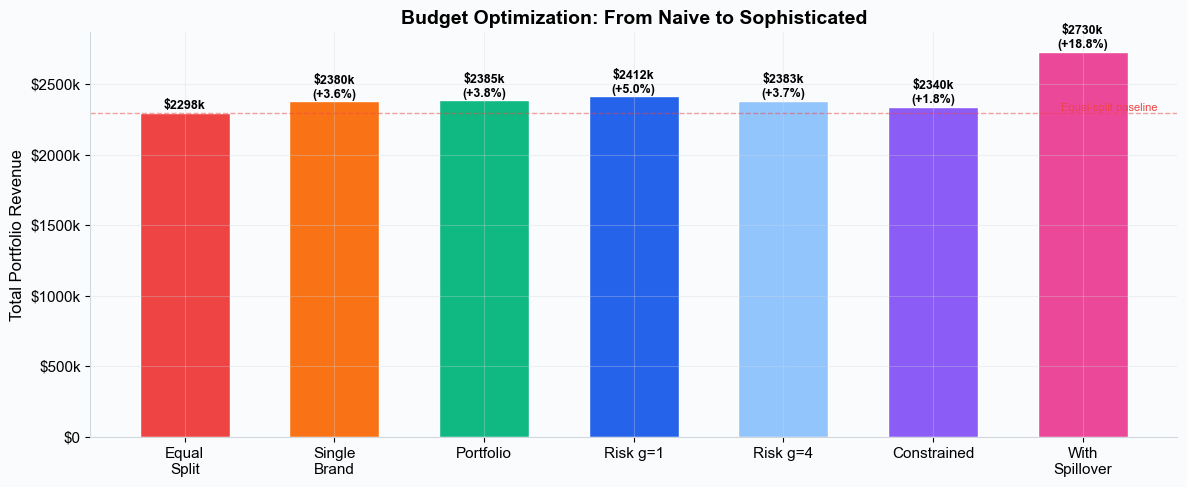


Key takeaways:
1. Just reshuffling within brands (single-brand): +3.6% lift
2. Letting budget flow between brands (portfolio): +3.8% lift
3. Constraints cost $45,093 vs unconstrained optimal
4. Spillover adds $344,200 by recognizing cross-brand effects


In [21]:
# === Chart: Summary comparison ===
fig, ax = plt.subplots(figsize=(12, 5))
scenario_names = ['Equal\nSplit', 'Single\nBrand', 'Portfolio', 'Risk g=1', 'Risk g=4',
                  'Constrained', 'With\nSpillover']
scenario_revenues = [equal_revenue, total_single, optimal_revenue,
                     risk_results[1.0]['mean_revenue'], risk_results[4.0]['mean_revenue'],
                     constrained_revenue, spill_revenue]
scenario_colors = [COLORS[3], COLORS[1], COLORS[2], COLORS[0], '#93C5FD', COLORS[4], COLORS[5]]

bars = ax.bar(scenario_names, scenario_revenues, color=scenario_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, scenario_revenues):
    lift = (val / equal_revenue - 1) * 100
    label = f'${val/1000:.0f}k'
    if lift != 0:
        label += f'\n({lift:+.1f}%)'
    ax.text(bar.get_x() + bar.get_width()/2, val + 3000,
            label, ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency))
ax.set_ylabel('Total Portfolio Revenue')
ax.set_title('Budget Optimization: From Naive to Sophisticated', fontsize=14, fontweight='bold')
ax.axhline(equal_revenue, color=COLORS[3], linestyle='--', alpha=0.5, linewidth=1)
ax.text(6.5, equal_revenue, 'Equal-split baseline', fontsize=8, color=COLORS[3], ha='right', va='bottom')
plt.tight_layout()
plt.savefig('images/04_results_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

print('\nKey takeaways:')
print(f'1. Just reshuffling within brands (single-brand): +{(total_single/equal_revenue-1)*100:.1f}% lift')
print(f'2. Letting budget flow between brands (portfolio): +{(optimal_revenue/equal_revenue-1)*100:.1f}% lift')
print(f'3. Constraints cost ${cost_of_constraints:,.0f} vs unconstrained optimal')
print(f'4. Spillover adds ${spill_revenue - optimal_revenue:,.0f} by recognizing cross-brand effects')

---

## Next Steps

**Other notebooks in this series:**
- [Notebook 05: Adstock Effects](./05-adstock-effects.ipynb) -- How carryover and lag change optimization
- [Notebook 08: Saturation Curves](./08-saturation-curves.ipynb) -- Deep dive into the response functions used here
- [Notebook 11: Scenario Planning](./11-scenario-planning.ipynb) -- What-if analysis on optimized budgets
- [Notebook 12: Halo Effects](./12-halo-and-trademark-effects.ipynb) -- Cross-brand spillover modeling in detail

**Core concepts:**
- [Saturation Curves](../docs/core-concepts/saturation-curves.md) -- Why diminishing returns drive optimization
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md) -- Uncertainty quantification for risk adjustment
- [Halo Effects](../docs/core-concepts/halo-effects.md) -- Theory behind cross-brand spillover
- [Optimization](../docs/core-concepts/budget-optimization.md) -- The full mathematical framework